In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import torch
import torch.nn as nn
from torch.nn import Sequential
import torch.nn.functional as F
from torch.autograd import grad

In [3]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
np.random.seed(42)
torch.random.manual_seed(42)
print(device)

cuda:0


In [4]:
class Atan(torch.nn.Module):
  def forward(self, X):
    return torch.atan(X)
class kTanh(torch.nn.Module):
  def __init__(self, p):
    super().__init__()
    self.p = p
  def forward(self, X):
    return torch.tanh(self.p * X)
class PINN(torch.nn.Module):
  def __init__(self, n_hidden=4, n_neurons=64):
    super().__init__()
    self.gamma = 1.4
    self.net = Sequential()
    self.net.add_module('In_Linear', nn.Linear(2, n_neurons))
    self.net.add_module('In_Tanh', nn.Tanh())
    #self.net.add_module('In_Tanh', kTanh(2))
    for l in range(1, n_hidden+1):
      self.net.add_module(f'H_Linear_{l}', nn.Linear(n_neurons, n_neurons))
      self.net.add_module(f'H_Tanh_{l}', nn.Tanh())
      #self.net.add_module(f'H_Tanh_{l}', kTanh(2))
    self.net.add_module('Out_Linear', nn.Linear(n_neurons, 3))
    '''
    def init_weights(m):
      if type(m) == nn.Linear:
        torch.nn.init.xavier_uniform_(m.weight)
    self.net.apply(init_weights)
    '''
  def forward(self, X):
    return self.net(X)

  def f(self, x, t, Yf):
    rho, u, p = Yf
    Et = p / (self.gamma-1) + 0.5*rho*torch.square(u)

    Dt_rho = grad(rho, t, create_graph=True, grad_outputs=torch.ones_like(rho))[0]
    Dx_rho_u = grad(rho * u, x, create_graph=True, grad_outputs=torch.ones_like(rho * u))[0]
    eq1 = Dt_rho + Dx_rho_u
    f1 = F.mse_loss(eq1, torch.zeros_like(eq1))

    Dt_rho_u = grad(rho * u, t, create_graph=True, grad_outputs=torch.ones_like(rho * u))[0]
    Dx_rho_uu = grad(rho * torch.square(u), x, create_graph=True, grad_outputs=torch.ones_like(rho * torch.square(u)))[0]
    Dx_p = grad(p, x, create_graph=True, grad_outputs=torch.ones_like(p))[0]
    eq2 = Dt_rho_u + Dx_rho_uu + Dx_p
    f2 = F.mse_loss(eq2, torch.zeros_like(eq2))

    Dt_Et = grad(Et, t, create_graph=True, grad_outputs=torch.ones_like(Et))[0]
    Dx_Et_u = grad(Et * u, x, create_graph=True, grad_outputs=torch.ones_like(Et * u))[0]
    Dx_pu = grad(p * u, x, create_graph=True, grad_outputs=torch.ones_like(p * u))[0]
    eq3 = Dt_Et + Dx_Et_u + Dx_pu
    f3 = F.mse_loss(eq3, torch.zeros_like(eq3))

    f_loss = f1 + f2 + f3
    return f_loss

  def loss(self, Xdata, Ydata, Xf):
    losses = []
    losses.append(F.mse_loss(Ydata[0], self.forward(Xdata[0])))
    losses.append(F.mse_loss(Ydata[1], self.forward(Xdata[1])))
    Xf.requires_grad = True
    x = Xf[:, 0]
    t = Xf[:, 1]
    Xf = torch.concatenate([x.reshape(-1, 1), t.reshape(-1, 1)], axis=1)
    Yf = self.forward(Xf)
    Yf = [Yf[:, i] for i in range(3)]
    losses.append(self.f(x, t, Yf))
    return losses

In [5]:
def train(epochs):
  for epoch in range(1, epochs+1):
    model.train()
    losses = model.loss(Xdata, Ydata, Xf)
    loss = (1-_lambda) * (losses[0] + losses[1]) + _lambda * losses[2]
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if epoch % 1000 == 0:
      print(f'epoch = {epoch}, loss = {loss}, loss_data = {losses[0] + losses[1]}, loss_pde = {losses[2]}')

In [6]:
def validate(file_name):
  Yhat = model(X)
  Yhat_val = Yhat.detach().cpu().numpy()
  Yhat_val = [Yhat_val[:, i].reshape(Nt, Nx).T for i in range(3)]

  fig, axs = plt.subplots(1, 3, figsize=(10, 4))
  data = np.load(file_name, allow_pickle=True)

  for i, var in enumerate(['rho', 'u', 'p']):
    axs[i].plot(data['x'], data['U'][i][:, -1], label=f'exact {var}', color='green', linestyle='dashed')
    axs[i].plot(x, Yhat_val[i][:, -1], label=f'pinn {var}', color='red', linestyle='dotted')
    axs[i].set_xlabel('x')
    axs[i].set_ylabel(var)
    axs[i].legend()
  plt.tight_layout()

In [7]:
Nx = 256
Nt = 256

In [8]:
x = np.linspace(0, 1, Nx)
t = np.linspace(0, 0.1, Nt)

xx, tt = np.meshgrid(x, t, indexing='xy')
xx = xx.reshape(-1, 1)
tt = tt.reshape(-1, 1)

X = np.concatenate([xx, tt], axis=1)

In [9]:
xic = x.reshape(-1, 1)
tic = np.zeros((Nx, 1))

rho_ic = np.where(xic <= 0.5, 1, 0.125).reshape(-1, 1)
u_ic = np.zeros(Nx).reshape(-1, 1)
p_ic = np.where(xic <= 0.5, 1, 0.1).reshape(-1, 1)

Xic = np.concatenate([xic, tic], axis=1)
Yic = np.concatenate([rho_ic, u_ic, p_ic], axis=1)

In [10]:
Nic = 30 
indx_ic = np.random.choice(Nx, Nic, replace=False)
Xic = Xic[indx_ic]
Yic = Yic[indx_ic]


In [11]:

xbc = np.repeat([0, 1], Nt).reshape(-1, 1)
tbc = np.tile(t, 2).reshape(-1, 1)

Ybc = np.concatenate([np.repeat([coords[0], coords[1]], Nt).reshape(-1, 1) for coords in [[1, 0.125], [0, 0], [1, 0.1]]], axis=1)
Xbc = np.concatenate([xbc, tbc], axis=1)


In [12]:

Nbc = 50
indx_bc = np.random.choice(2 * Nt, Nbc, replace=False)
Xbc = Xbc[indx_bc]
Ybc = Ybc[indx_bc]


In [13]:
Nf = 13600

indx_f = np.random.choice(Nx * Nt, Nf, replace=False)
Xf = X[indx_f]


In [14]:
X = torch.tensor(X, dtype=torch.float, device=device)
Xf = torch.tensor(Xf, dtype=torch.float, device=device)
Xic = torch.tensor(Xic, dtype=torch.float, device=device)
Xbc = torch.tensor(Xbc, dtype=torch.float, device=device)

Yic = torch.tensor(Yic, dtype=torch.float, device=device)
Ybc = torch.tensor(Ybc, dtype=torch.float, device=device)

In [15]:
Xdata = [Xic, Xbc]
Ydata = [Yic, Ybc]

In [16]:
(Nx, Nt), (Xic.shape, Yic.shape), (Xbc.shape, Ybc.shape), (Xf.shape, X.shape)

((256, 256),
 (torch.Size([30, 2]), torch.Size([30, 3])),
 (torch.Size([50, 2]), torch.Size([50, 3])),
 (torch.Size([13600, 2]), torch.Size([65536, 2])))

In [17]:
model = PINN(n_hidden=10, n_neurons=20).to(device) 
model

PINN(
  (net): Sequential(
    (In_Linear): Linear(in_features=2, out_features=20, bias=True)
    (In_Tanh): Tanh()
    (H_Linear_1): Linear(in_features=20, out_features=20, bias=True)
    (H_Tanh_1): Tanh()
    (H_Linear_2): Linear(in_features=20, out_features=20, bias=True)
    (H_Tanh_2): Tanh()
    (H_Linear_3): Linear(in_features=20, out_features=20, bias=True)
    (H_Tanh_3): Tanh()
    (H_Linear_4): Linear(in_features=20, out_features=20, bias=True)
    (H_Tanh_4): Tanh()
    (H_Linear_5): Linear(in_features=20, out_features=20, bias=True)
    (H_Tanh_5): Tanh()
    (H_Linear_6): Linear(in_features=20, out_features=20, bias=True)
    (H_Tanh_6): Tanh()
    (H_Linear_7): Linear(in_features=20, out_features=20, bias=True)
    (H_Tanh_7): Tanh()
    (H_Linear_8): Linear(in_features=20, out_features=20, bias=True)
    (H_Tanh_8): Tanh()
    (H_Linear_9): Linear(in_features=20, out_features=20, bias=True)
    (H_Tanh_9): Tanh()
    (H_Linear_10): Linear(in_features=20, out_features=2

In [18]:
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4) 

In [19]:
_lambda = 5.3e-4 #best


In [20]:
epochs = 40000
train(epochs)

epoch = 1000, loss = 0.00513471569865942, loss_data = 0.0017234811093658209, loss_pde = 6.438015460968018
epoch = 2000, loss = 0.00437534973025322, loss_data = 0.001673434511758387, loss_pde = 5.0996270179748535
epoch = 3000, loss = 0.004296399187296629, loss_data = 0.0016595595516264439, loss_pde = 4.976828098297119
epoch = 4000, loss = 0.004197395872324705, loss_data = 0.0016147559508681297, loss_pde = 4.874520301818848
epoch = 5000, loss = 0.00034442025935277343, loss_data = 8.492729830322787e-05, loss_pde = 0.4896942973136902
epoch = 6000, loss = 0.00012044014874845743, loss_data = 1.4976045349612832e-05, loss_pde = 0.19900384545326233
epoch = 7000, loss = 9.909295476973057e-05, loss_data = 1.063559375324985e-05, loss_pde = 0.166911318898201
epoch = 8000, loss = 8.647835784358904e-05, loss_data = 8.829481885186397e-06, loss_pde = 0.1465161293745041
epoch = 9000, loss = 7.595273928018287e-05, loss_data = 7.2894331424322445e-06, loss_pde = 0.1295606940984726
epoch = 10000, loss = 6.7

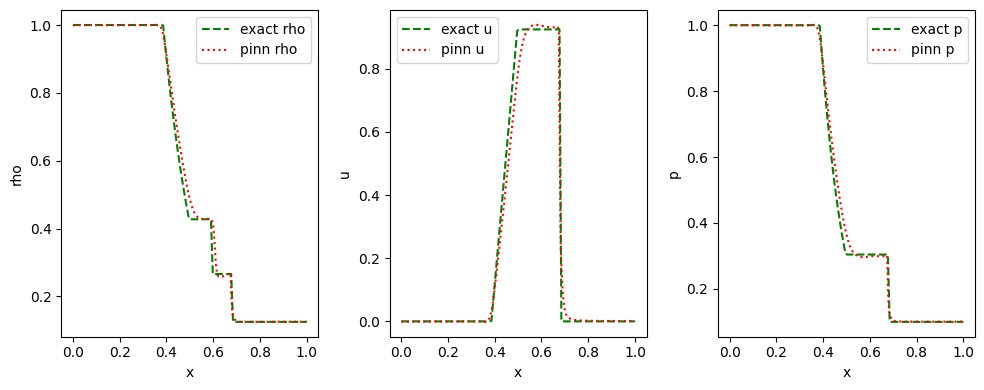

In [21]:
validate('/kaggle/input/pinn-dataset/euler_1d_data.npz')

In [22]:
Yhat = model(X)
Yhat_val = Yhat.detach().cpu().numpy()
Yhat_val = [Yhat_val[:, i].reshape(Nt, Nx).T for i in range(3)]

In [23]:
np.savez('solution', x=x, Yhat_val=Yhat_val)

In [24]:
torch.save(model.state_dict(), 'model')